
=== DIAGNÓSTICO PRE-FILTRO ===
obs_ID únicos (raw): ['06_SPOT_AR1' '04_QSUN_QS4ab']
line únicos (raw):   [525.02 517.  ]

obs_ID únicos (normalizado, repr de primeros 10):
["'nan'", "'06_SPOT_AR1'", "'04_QSUN_QS4ab'"]
line únicos (normalizado texto, repr primeros 10):
["'nan'", "'525.02'", "'517.0'"]
line únicos (num, primeros 10): [525.02, 517.0]

Buscando obs_ID == '06_SPOT_AR1'  |  line == '517.0' (y 517.0 num si aplica)
Coincidencias por obs_ID (solo): 163
Coincidencias por line texto (solo): 83
Coincidencias por line numérico (solo): 83

Filas tras filtro combinado: 83


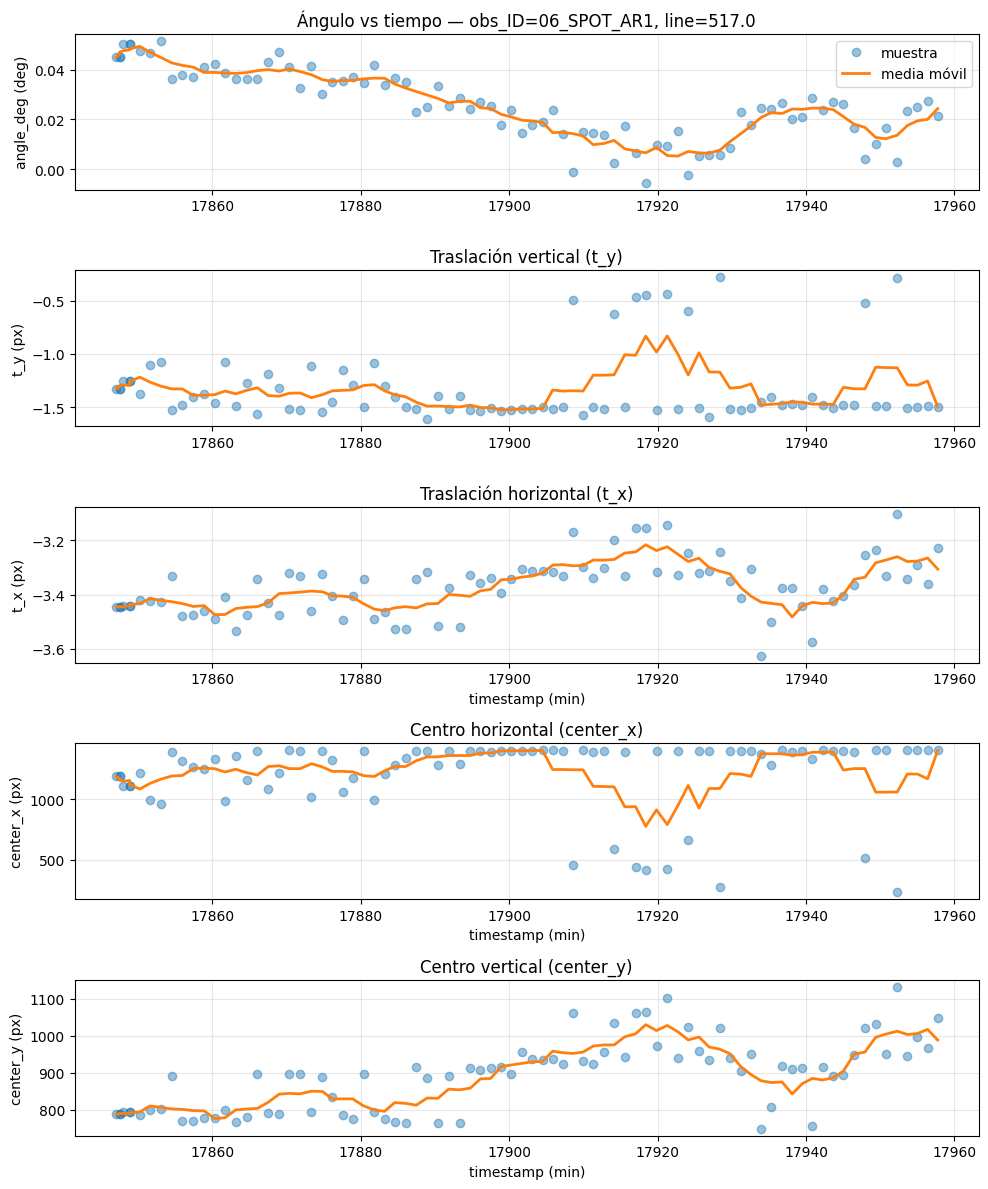

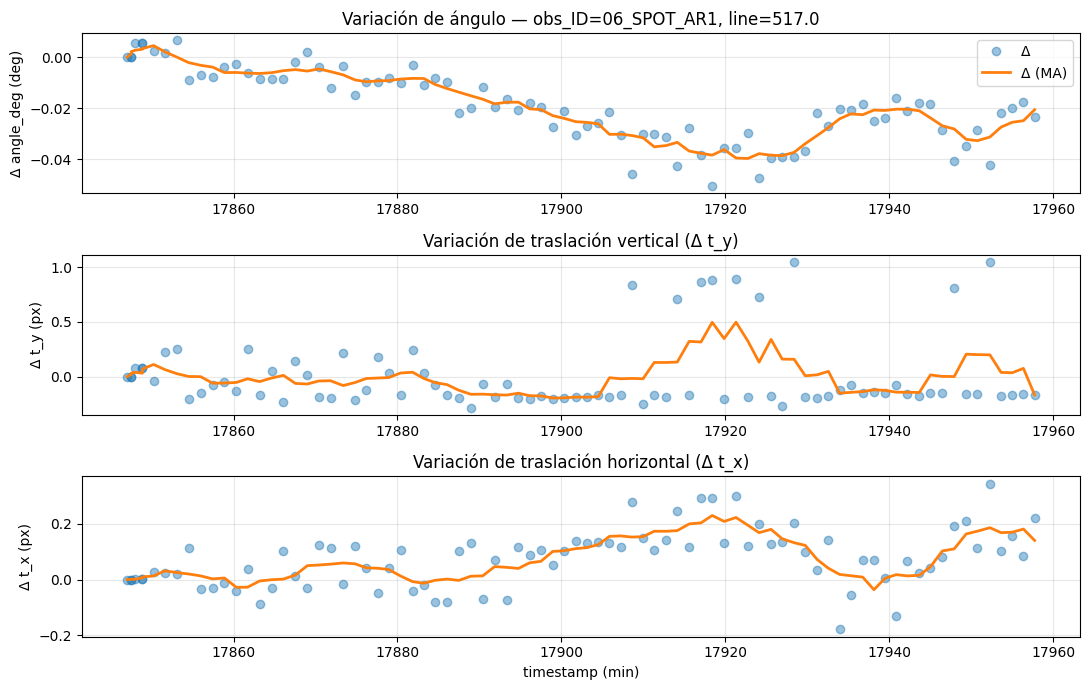

In [23]:
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt

# === 1) Configuración ===
csv_path = "alignment_results.csv"
rolling_window = 6
show_deltas = True
save_figs = False

selected_obs_ID = "06_SPOT_AR1" #"04_QSUN_QS4ab"   # <-- tu obs_ID
selected_line   = "517.0"# "525.02"          # <-- tu línea (puede venir como float en CSV)

# === 2) Leer CSV ===
df = pd.read_csv(csv_path)

# Asegurar columnas mínimas
required_cols = {'timestamp', 'angle_deg', 't_y', 't_x',
                 'center_x','center_y','obs_ID','line'}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas en el CSV: {missing}")

# === 3) Normalizar obs_ID y line (texto) ===
def _norm_str_series(s: pd.Series) -> pd.Series:
    # A texto, normaliza unicode, colapsa espacios y recorta
    s = s.astype(str)
    s = s.apply(lambda x: unicodedata.normalize('NFKC', x))
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()
    return s

# Crear columnas normalizadas (texto)
df['_obs_ID_str'] = _norm_str_series(df['obs_ID'])
df['_line_str']   = _norm_str_series(df['line'])

# Además, preparar 'line' como número cuando sea posible (para casos 525.02 vs "525.02")
def _to_float_or_nan(x):
    try:
        return float(x)
    except Exception:
        return np.nan

df['_line_num'] = df['_line_str'].apply(_to_float_or_nan)

# Preparar también los valores buscados en ambas formas
obs_id_key_str = unicodedata.normalize('NFKC', str(selected_obs_ID)).strip()
line_key_str   = unicodedata.normalize('NFKC', str(selected_line)).strip()
try:
    line_key_num = float(line_key_str)
except Exception:
    line_key_num = np.nan

# === 4) Diagnóstico antes del filtro ===
print("\n=== DIAGNÓSTICO PRE-FILTRO ===")
print("obs_ID únicos (raw):", df['obs_ID'].dropna().unique()[:10])
print("line únicos (raw):  ", df['line'].dropna().unique()[:10])

print("\nobs_ID únicos (normalizado, repr de primeros 10):")
print([repr(x) for x in df['_obs_ID_str'].unique()[:10]])

print("line únicos (normalizado texto, repr primeros 10):")
print([repr(x) for x in df['_line_str'].unique()[:10]])

print("line únicos (num, primeros 10):",
      pd.Series(df['_line_num'].unique()).dropna().head(10).tolist())

print(f"\nBuscando obs_ID == {repr(obs_id_key_str)}  |  line == {repr(line_key_str)} (y {line_key_num} num si aplica)")

# ¿Cuántos emparejan por obs_ID solamente?
n_obs = (df['_obs_ID_str'] == obs_id_key_str).sum()
print(f"Coincidencias por obs_ID (solo): {n_obs}")

# ¿Cuántos emparejan por line como texto?
n_line_txt = (df['_line_str'] == line_key_str).sum()
print(f"Coincidencias por line texto (solo): {n_line_txt}")

# ¿Cuántos emparejan por line como número? (si es convertible)
if np.isfinite(line_key_num):
    n_line_num = (np.isclose(df['_line_num'], line_key_num, rtol=0, atol=1e-9)).sum()
    print(f"Coincidencias por line numérico (solo): {n_line_num}")

# === 5) Filtro robusto: intentar primero numérico si posible; si no, textual ===
if np.isfinite(line_key_num):
    filt = ((df['_obs_ID_str'] == obs_id_key_str) &
            (np.isclose(df['_line_num'], line_key_num, rtol=0, atol=1e-9)))
else:
    filt = ((df['_obs_ID_str'] == obs_id_key_str) &
            (df['_line_str'] == line_key_str))

df = df.loc[filt].copy()
print(f"\nFilas tras filtro combinado: {len(df)}")

if df.empty:
    # DUMP pequeño de ejemplo cuando nada encaja
    print("\n>>> Muestra de filas con obs_ID coincidente pero line distinto (primeras 5):")
    m_obs = (df['_obs_ID_str'] == obs_id_key_str)
    print(df.loc[m_obs].head())
    raise ValueError(f"No hay datos para obs_ID='{selected_obs_ID}' y line='{selected_line}' (revisa espacios/tipos).")

# === 6) Orden temporal y resto del flujo ===
df = df.sort_values('timestamp').reset_index(drop=True)

# Medias móviles
for col in ['angle_deg', 't_y', 't_x', 'center_x', 'center_y']:
    df[col + '_ma'] = df[col].rolling(rolling_window, center=True, min_periods=1).mean()

# Deltas
if show_deltas:
    for col in ['angle_deg', 't_y', 't_x', 'center_x', 'center_y']:
        df['delta_' + col] = df[col] - df[col].iloc[0]
        df['delta_' + col + '_ma'] = df['delta_' + col].rolling(
            rolling_window, center=True, min_periods=1).mean()

# === 7) Gráficas ===
plt.figure(figsize=(10, 12))

ax1 = plt.subplot(5, 1, 1)
ax1.plot(df['timestamp'], df['angle_deg'], 'o', alpha=0.45, label='muestra')
ax1.plot(df['timestamp'], df['angle_deg_ma'], '-', lw=2, label='media móvil')
ax1.set_title(f'Ángulo vs tiempo — obs_ID={selected_obs_ID}, line={selected_line}')
ax1.set_ylabel('angle_deg (deg)')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = plt.subplot(5, 1, 2, sharex=ax1)
ax2.plot(df['timestamp'], df['t_y'], 'o', alpha=0.45)
ax2.plot(df['timestamp'], df['t_y_ma'], '-', lw=2)
ax2.set_title('Traslación vertical (t_y)')
ax2.set_ylabel('t_y (px)')
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(5, 1, 3, sharex=ax1)
ax3.plot(df['timestamp'], df['t_x'], 'o', alpha=0.45)
ax3.plot(df['timestamp'], df['t_x_ma'], '-', lw=2)
ax3.set_title('Traslación horizontal (t_x)')
ax3.set_xlabel('timestamp (min)')
ax3.set_ylabel('t_x (px)')
ax3.grid(True, alpha=0.3)

ax4 = plt.subplot(5, 1, 4, sharex=ax1)
ax4.plot(df['timestamp'], df['center_x'], 'o', alpha=0.45)
ax4.plot(df['timestamp'], df['center_x_ma'], '-', lw=2)
ax4.set_title('Centro horizontal (center_x)')
ax4.set_xlabel('timestamp (min)')
ax4.set_ylabel('center_x (px)')
ax4.grid(True, alpha=0.3)

ax5 = plt.subplot(5, 1, 5, sharex=ax1)
ax5.plot(df['timestamp'], df['center_y'], 'o', alpha=0.45)
ax5.plot(df['timestamp'], df['center_y_ma'], '-', lw=2)
ax5.set_title('Centro vertical (center_y)')
ax5.set_xlabel('timestamp (min)')
ax5.set_ylabel('center_y (px)')
ax5.grid(True, alpha=0.3)

plt.tight_layout()
if save_figs:
    safe_obs = obs_id_key_str.replace(' ', '_')
    safe_line = line_key_str.replace(' ', '_')
    plt.savefig(f'abs_{safe_obs}_{safe_line}.png', dpi=150)
plt.show()

if show_deltas:
    plt.figure(figsize=(11, 7))

    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(df['timestamp'], df['delta_angle_deg'], 'o', alpha=0.45, label='Δ')
    ax1.plot(df['timestamp'], df['delta_angle_deg_ma'], '-', lw=2, label='Δ (MA)')
    ax1.set_title(f'Variación de ángulo — obs_ID={selected_obs_ID}, line={selected_line}')
    ax1.set_ylabel('Δ angle_deg (deg)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.plot(df['timestamp'], df['delta_t_y'], 'o', alpha=0.45)
    ax2.plot(df['timestamp'], df['delta_t_y_ma'], '-', lw=2)
    ax2.set_title('Variación de traslación vertical (Δ t_y)')
    ax2.set_ylabel('Δ t_y (px)')
    ax2.grid(True, alpha=0.3)

    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.plot(df['timestamp'], df['delta_t_x'], 'o', alpha=0.45)
    ax3.plot(df['timestamp'], df['delta_t_x_ma'], '-', lw=2)
    ax3.set_title('Variación de traslación horizontal (Δ t_x)')
    ax3.set_xlabel('timestamp (min)')
    ax3.set_ylabel('Δ t_x (px)')
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_figs:
        plt.savefig(f'delta_{safe_obs}_{safe_line}.png', dpi=150)
    plt.show()

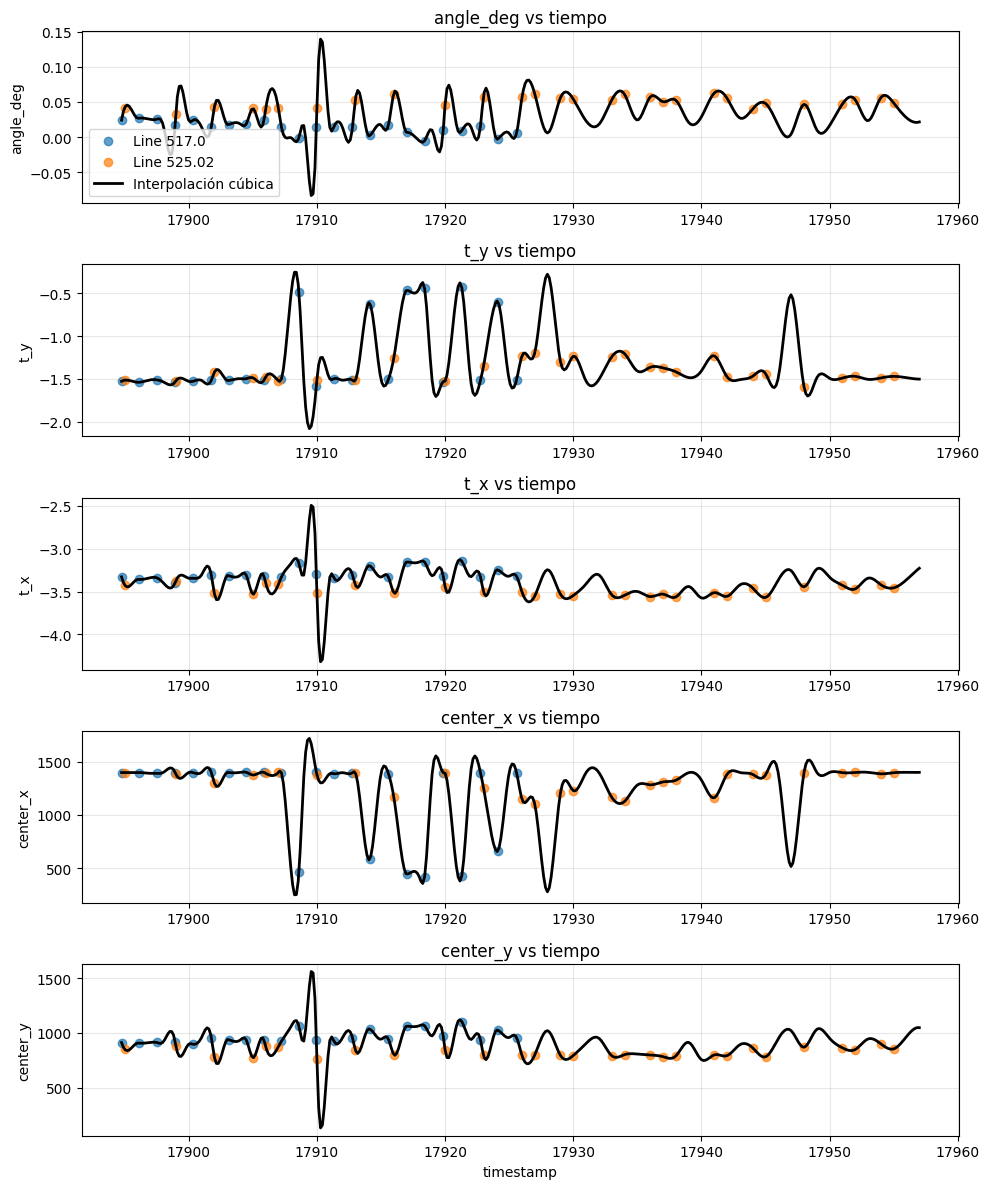

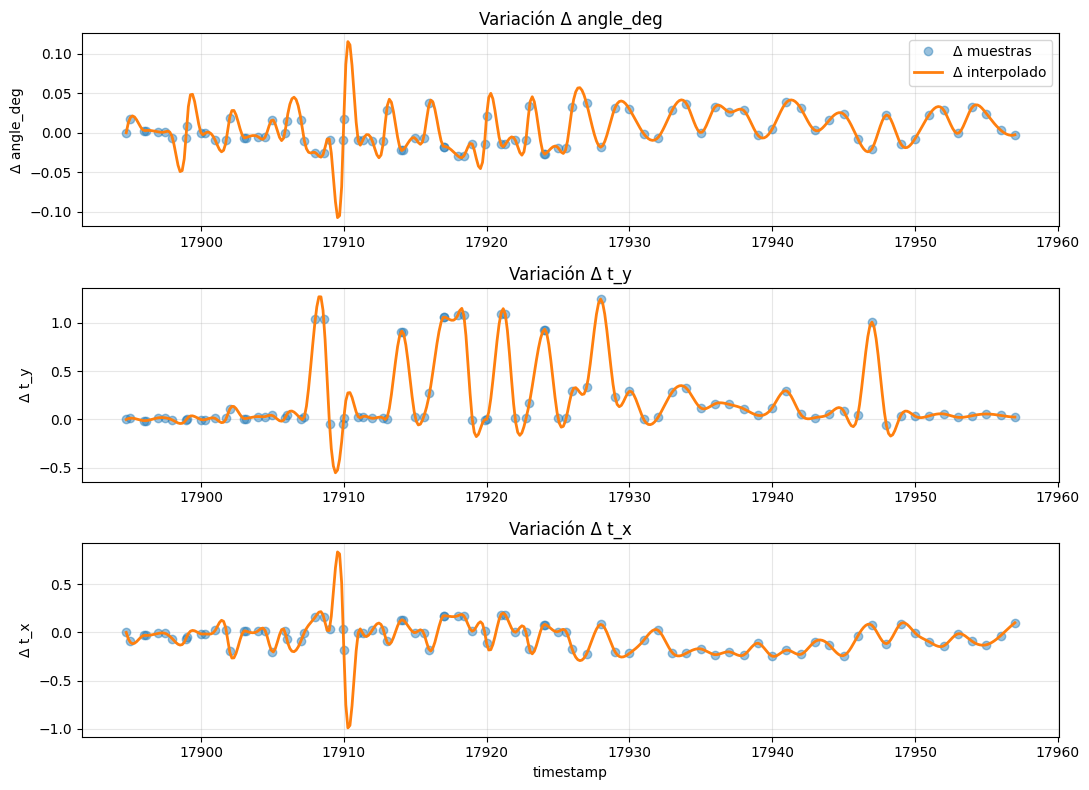

In [ ]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# === 1) Configuración ===
csv_path = "alignment_results.csv"
show_deltas = True
save_figs = False

# === 2) Leer y preparar datos ===
df = pd.read_csv(csv_path)

required_cols = {'timestamp', 'angle_deg', 't_y', 't_x', 'center_x', 'center_y'}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas en el CSV: {missing}")

df = df.sort_values('timestamp').reset_index(drop=True)
df = df.drop_duplicates(subset=['timestamp'], keep='first').reset_index(drop=True)

# Selección de rango
start_idx = 16
end_idx = -1
start_idx = 
end_idx = -1

df = df.iloc[start_idx:end_idx]

timestamps = df['timestamp'].values

# Crear timestamps interpolados (curva suave)
timestamps_interp = np.linspace(
    timestamps.min(),
    timestamps.max(),
    len(timestamps) * 5
)

# === 3) Interpolación cúbica ===
cols = ['angle_deg', 't_y', 't_x', 'center_x', 'center_y']
interp_data = {}

# Get unique lines for color mapping
unique_lines = df['line'].dropna().unique()
line_colors = {line: plt.cm.tab10(i) for i, line in enumerate(sorted(unique_lines))}

for col in cols:
    interp_func = interp1d(
        timestamps,
        df[col].values,
        kind='cubic',
        fill_value="extrapolate"
    )

    # Guardar valores interpolados densos
    interp_data[col] = interp_func(timestamps_interp)

# === 4) Variaciones (Δ) ===
delta_interp_data = {}

if show_deltas:
    for col in cols:
        df['delta_' + col] = df[col] - df[col].iloc[0]

        interp_func = interp1d(
            timestamps,
            df['delta_' + col].values,
            kind='cubic',
            fill_value="extrapolate"
        )

        delta_interp_data[col] = interp_func(timestamps_interp)

# === 5) Figura: valores absolutos ===
plt.figure(figsize=(10, 12))

for i, col in enumerate(cols):
    ax = plt.subplot(5, 1, i + 1)

    # --- Puntos originales coloreados por line ---
    for line_value in unique_lines:
        mask = df['line'] == line_value
        ax.plot(
            df.loc[mask, 'timestamp'],
            df.loc[mask, col],
            'o',
            alpha=0.7,
            color=line_colors[line_value],
            label=f'Line {line_value}'
        )

    # Curva interpolada
    ax.plot(
        timestamps_interp,
        interp_data[col],
        '-',
        lw=2,
        color='black',
        label='Interpolación cúbica'
    )

    ax.set_title(f'{col} vs tiempo')
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend()

    if i == len(cols) - 1:
        ax.set_xlabel('timestamp')

plt.tight_layout()

# === 6) Figura: variaciones (Δ) ===
if show_deltas:
    plt.figure(figsize=(11, 8))

    delta_cols = ['angle_deg', 't_y', 't_x']

    for i, col in enumerate(delta_cols):
        ax = plt.subplot(3, 1, i + 1)

        ax.plot(df['timestamp'],
                df['delta_' + col],
                'o',
                alpha=0.45,
                label='Δ muestras')

        ax.plot(timestamps_interp,
                delta_interp_data[col],
                '-',
                lw=2,
                label='Δ interpolado')

        ax.set_title(f'Variación Δ {col}')
        ax.set_ylabel(f'Δ {col}')
        ax.grid(True, alpha=0.3)

        if i == 0:
            ax.legend()

        if i == len(delta_cols) - 1:
            ax.set_xlabel('timestamp')

    plt.tight_layout()

    if save_figs:
        plt.savefig('valores_delta.png', dpi=150)

    plt.show()


In [10]:
fits_file = "/Users/orozco/IdAdA Dropbox/David orozco suárez/Python/TuMAG_codes/TuMags_Reduction_Pipeline/Analysis/Nuevo alineamiento/reduccion/06_SPOT_AR1/06_SPOT_AR1_TM_Mg_10_12072024T092851_LV_1.0caso20_v0.1.fits"

In [11]:
from astropy.io import fits

In [12]:
# read data — use the renamed path variable `fits_file` to avoid shadowing the fits module
with fits.open(fits_file) as hdul:
    data = hdul[0].data
    header = hdul[0].header


In [13]:
header

SIMPLE  =                    T / FITS: file conforms to standard                
BITPIX  =                  -64 / FITS: number of bits per data pixel            
NAXIS   =                    4 / FITS: number of data axes                      
NAXIS1  =                 1600 / FITS: axis 1 length                            
NAXIS2  =                 1600 / FITS: axis 2 length                            
NAXIS3  =                    4 / FITS: axis 2 length                            
NAXIS4  =                   10                                                  
EXTEND  =                    T / FITS: may contain extensions                   
PPL_VER = '0.1     '           / Pipeline version                               
LEVEL   = '0.5     '           / Level of reduction                             
BUNIT   = 'DN      '           / Physical units of array values                 
DATATYPE= 'SCIENCE '           / Data type: DARK / FLAT / SCIENCE               
INSTRUME= 'TuMag   '        